In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
import numpy.random as random

# ２）	M/M/c/cのシミュレーション

In [2]:
#逆関数法による指数乱数の発生
def exp(x):
    y = random.random(1)
    X = -math.log(y)/x
    return(X)

In [3]:
### 到着率, サービス率, サーバ数を与えて平均系内人数と平均系内時間のリストを返す関数
def simulation_mmcc(lam,mu,c):
    j = 0 #系内人数
    j_before = 0 #計算用の系内人数
    time = 0 #時間
    time_include = 0 #実際の性能評価指標の計算に用いる時間
    interval = 0 #イベントの間隔
    cum_visitor = 0 #累計系内客数
    cum_visitor_before = 0 #計算から除外する累計系内客数
    sojourn_time = list() #系内時間記録用リスト
    arrive_time = list() #到着時刻記録用リスト
    finish_time = list() #サービス終了時刻記録用リスト
    numerator_EL_sim = 0 #平均系内客数の計算に利用(これをtime_includeで割り算する)

    Nt_list = [] #eventが発生した時刻の系内人数(離散値)
    event_time = [] #eventが発生した時刻
    block = 0 #ブロックされた人数


    for state in range(1,11000000):
        j_before = j
        #系内人数が0のとき:到着しか起こらない
        if j==0:
            j += 1
            interval = exp(lam)
            cum_visitor += 1
            arrive_time.append(time + interval)


        #系内人数が1〜c人の場合:サービス率が人数によって変動する
        elif j<=c:
            a = exp(lam)
            b = exp(j*mu)
            #到着
            if a==min(a,b):
                j += 1
                interval = a
                cum_visitor += 1
                arrive_time.append(time + interval)
                if (j > c):
                    block += 1
                    j -= 1

            #サービス完了
            else:
                j -= 1
                interval = b
                finish_time.append(time + interval)

        #系内人数がc+1人以上の場合:サービス率は常にc*mu（全サーバが稼働）
        else:
            a = exp(lam)
            b = exp(c*mu)
            if a==min(a,b):
                j += 1
                interval = a
                cum_visitor += 1
                arrive_time.append(time + interval)
                block += 1
                j -= 1
            else:
                j -= 1
                interval = b
                finish_time.append(time + interval)


        if state==1000000:
            cum_visitor_before = cum_visitor
            block_before = block


        if state>1000000:
            time_include += interval
            numerator_EL_sim += interval*j_before
            Nt_list.append(j)
            event_time.append(time_include)

        #時間の更新
        time+=interval

    ###性能評価指標の計算
    #平均系内客数
    EL_sim = numerator_EL_sim/time_include
    #棄却率
    block_rate = (block - block_before)/(cum_visitor - cum_visitor_before)
    #平均系内時間
    for x in range(cum_visitor_before-1,len(finish_time)):
        sojourn_time.append(finish_time[x]-arrive_time[x])


    return EL_sim, Nt_list, event_time, block_rate, sojourn_time

In [4]:
MMCC_EL_sim, MMCC_Nt_list, MMCC_event_time, MMCC_block_rate, MMCC_sojourn_time = simulation_mmcc(8,10,3)

<ipython-input-2-4101260141>:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X = -math.log(y)/x


### サンプルパスのplot

In [5]:
def MMCC_Ntplot(MMCC_event_time,MMCC_Nt_list):
    time_stamp = np.linspace(0,int(MMCC_event_time[-1]),1000001) #時間間隔
    MMCC_Nt_transition = []
    C = 0

    for i in time_stamp:
        while (i > MMCC_event_time[C]):
            C += 1
        if (C == 0):
            MMCC_Nt_transition.append(MMCC_Nt_list[0])
        else:
            MMCC_Nt_transition.append(MMCC_Nt_list[C-1])

    plt.plot(time_stamp,MMCC_Nt_transition)
    plt.xlim(0,5)
    plt.show()

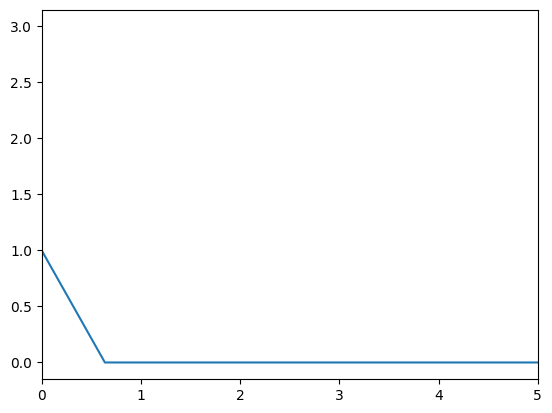

In [6]:
MMCC_Ntplot(MMCC_event_time,MMCC_Nt_list)

### 系内客数の分布

In [7]:
def MMCC_distribution(lam,mu,c,MMCC_event_time, MMCC_Nt_list):
    time_stamp = np.linspace(0,int(MMCC_event_time[-1]),1000001) #時間間隔
    C = 0
    N = []

    for i in time_stamp:
        while (i > MMCC_event_time[C]):
            C += 1
        if (C == 0):
            N.append(MMCC_Nt_list[0])
        else:
            N.append(MMCC_Nt_list[C-1])

    dist = {}
    x = []
    y = []
    for i in N:
        if i in dist.keys():
            dist[i] += 1
        else:
            dist[i] = 1

    for j in sorted(dist.keys()):
        dist[j] = dist[j]/len(N)
        x.append(j)
        y.append(dist[j])



    fig = plt.figure()
    ax = fig.add_subplot(1,1,1)
    ax.plot(x,y)
    ax.set_xlabel("N(t)")
    ax.set_ylabel("Probability density")
    plt.show()

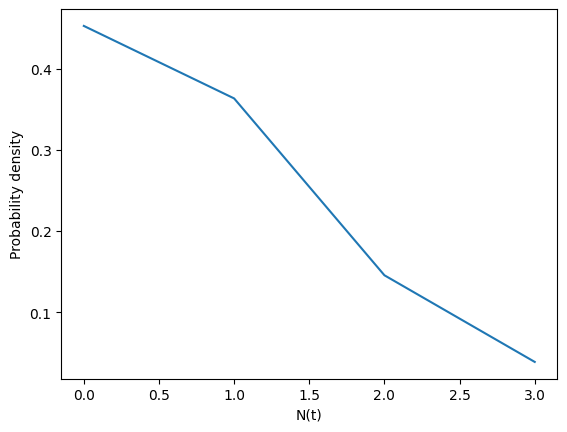

In [8]:
MMCC_distribution(8,10,3,MMCC_event_time, MMCC_Nt_list)

### 平均系内客数

In [9]:
print("平均系内客数")
print("シミュレーション結果：",MMCC_EL_sim)

平均系内客数
シミュレーション結果： 0.7691286826492088


### $P_{B}$：到着した客のうち、到着時にすぐにサービスを受けられず諦めなければならない確率

In [10]:
def MMCC_blocking_probability(lam,mu,c,MMCC_block_rate):
    sim_pb = MMCC_block_rate
    ρ = lam/mu
    A = (ρ**c)/math.factorial(c)
    B = 0
    for k in range(0,c+1):
        B += (ρ**k)/(math.factorial(k))

    theo_pb = A/B

    return sim_pb, theo_pb

In [11]:
sim_pb, theo_pb = MMCC_blocking_probability(8,10,3,MMCC_block_rate)

In [12]:
print("到着した客のうち、到着時にすぐにサービスを受けられず諦めなければならない確率")
print("シミュレーション結果：",sim_pb)
print("理論値：",theo_pb)

到着した客のうち、到着時にすぐにサービスを受けられず諦めなければならない確率
シミュレーション結果： 0.038774995082227315
理論値： 0.038694074969770266


### Cを$\infty$にした場合

In [13]:
MMCC_EL_sim, MMCC_Nt_list, MMCC_event_time, MMCC_block_rate = simulation_mmcc(8,10,math.inf)

<ipython-input-2-4101260141>:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X = -math.log(y)/x


ValueError: too many values to unpack (expected 4)

# 3）	M/M/cのシミュレーション

In [14]:
### 到着率, サービス率, サーバ数を与えて平均系内人数と平均系内時間のリストを返す関数
def simulation_mmc(lam,mu,c):
    j = 0 #系内人数
    j_before = 0 #計算用の系内人数
    time = 0 #時間
    time_include = 0 #実際の性能評価指標の計算に用いる時間
    interval = 0 #イベントの間隔
    cum_visitor = 0 #累計系内客数
    cum_visitor_before = 0 #計算から除外する累計系内客数
    sojourn_time = list() #系内時間記録用リスト
    arrive_time = list() #到着時刻記録用リスト
    finish_time = list() #サービス終了時刻記録用リスト
    numerator_EL_sim = 0 #平均系内客数の計算に利用(これをtime_includeで割り算する)

    Nt_list = [] #eventが発生した時刻の系内人数(離散値)
    event_time = [] #eventが発生した時刻
    wait = 0 #待たされた人数


    for state in range(1,110000):
        j_before = j
        if j==0: #系内人数が0のとき:到着しか起こらない
            j += 1
            interval = exp(lam)
            cum_visitor += 1
            arrive_time.append(time + interval)


        elif j<=c: #系内人数が1〜c人の場合:サービス率が人数によって変動する
            a = exp(lam)
            b = exp(j*mu)
            if a==min(a,b): #到着
                j += 1
                interval = a
                cum_visitor += 1
                arrive_time.append(time + interval)
                if (j > c):
                    wait += 1


            else: #サービス完了
                j -= 1
                interval = b
                finish_time.append(time + interval)


        else: #系内人数がc+1人以上の場合:サービス率は常にc*mu（全サーバが稼働）
            a = exp(lam)
            b = exp(c*mu)
            if a==min(a,b):
                j += 1
                interval = a
                cum_visitor += 1
                arrive_time.append(time + interval)
                wait += 1
            else:
                j -= 1
                interval = b
                finish_time.append(time + interval)


        if state==10000:
            cum_visitor_before = cum_visitor
            wait_before = wait

        if state>10000:
            time_include += interval
            numerator_EL_sim += interval*j_before
            Nt_list.append(j)
            event_time.append(time_include)

        time+=interval #時間の更新

    ###性能評価指標の計算
    #平均系内客数
    EL_sim = numerator_EL_sim/time_include
    #平均系内時間
    for x in range(cum_visitor_before-1,len(finish_time)):
        sojourn_time.append(finish_time[x]-arrive_time[x])

    wait_rate = (wait - wait_before)/(cum_visitor - cum_visitor_before)


    return EL_sim, Nt_list, event_time, wait_rate, sojourn_time

In [15]:
MMC_EL_sim, MMC_Nt_list, MMC_event_time, MMC_wait_rate, MMC_sojourn_time = simulation_mmc(8,10,3)

<ipython-input-2-4101260141>:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X = -math.log(y)/x


### サンプルパスのplot

In [16]:
def MMC_Ntplot(MMC_event_time,MMC_Nt_list):
    time_stamp = np.linspace(0,int(MMC_event_time[-1]),1000001) #時間間隔
    MMC_Nt_transition = []
    C = 0

    for i in time_stamp:
        while (i > MMC_event_time[C]):
            C += 1
        if (C == 0):
            MMC_Nt_transition.append(MMC_Nt_list[0])
        else:
            MMC_Nt_transition.append(MMC_Nt_list[C-1])


    plt.plot(time_stamp,MMC_Nt_transition)
    plt.xlim(0,5)
    plt.show()

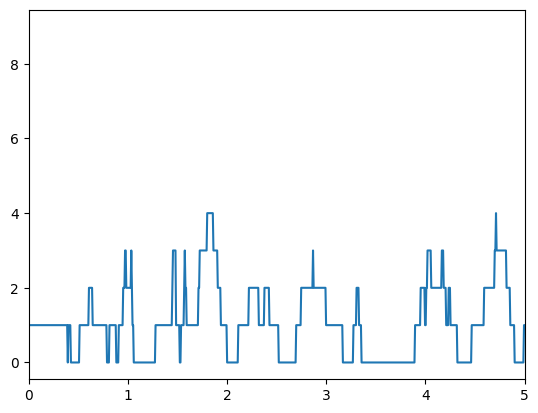

In [17]:
MMC_Ntplot(MMC_event_time,MMC_Nt_list)

### 系内客数の分布

In [18]:
def MMC_distribution(lam,mu,c,MMC_event_time, MMC_Nt_list):
    time_stamp = np.linspace(0,int(MMC_event_time[-1]),1000001) #時間間隔
    C = 0
    N = []

    for i in time_stamp:
        while (i > MMC_event_time[C]):
            C += 1
        if (C == 0):
            N.append(MMC_Nt_list[0])
        else:
            N.append(MMC_Nt_list[C-1])


    dist = {}
    x = []
    y = []
    for i in N:
        if i in dist.keys():
            dist[i] += 1
        else:
            dist[i] = 1

    for j in sorted(dist.keys()):
        dist[j] = dist[j]/len(N)
        x.append(j)
        y.append(dist[j])



    fig = plt.figure()
    ax = fig.add_subplot(1,1,1)
    ax.plot(x,y)
    ax.set_xlabel("N(t)")
    ax.set_ylabel("Probability density")
    plt.show()

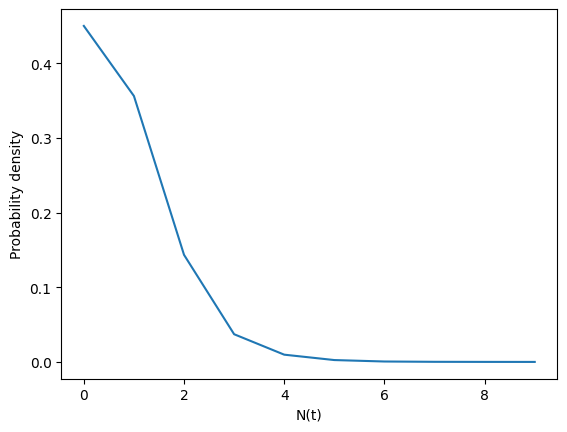

In [19]:
MMC_distribution(8,10,3,MMC_event_time, MMC_Nt_list)

### $P_{w}$：到着した客のうち、到着時にすぐにサービスを受けられず待たなければならない確率

In [20]:
def MMC_waiting_probability(lam,mu,c,MMC_wait_rate):
    sim_pw = MMC_wait_rate
    ρ = lam/mu
    A = (ρ**c)/math.factorial(c)
    B = 0
    for k in range(0,c):
        B += (ρ**k)/(math.factorial(k))

    theo_pw = A/((1-ρ/c)*B + A)

    return sim_pw, theo_pw

In [21]:
sim_pw, theo_pw = MMC_waiting_probability(8,10,3,MMC_wait_rate)

In [22]:
print("到着した客のうち、到着時にすぐにサービスを受けられず待たなければならない確率")
print("シミュレーション結果：",sim_pw)
print("理論値：",theo_pw)

到着した客のうち、到着時にすぐにサービスを受けられず待たなければならない確率
シミュレーション結果： 0.04928098561971239
理論値： 0.052032520325203266


### 平均系内客数

In [23]:
def MMC_mean_Nt(lam,mu,c,MMC_EL_sim,theo_pw):
    ρ= (lam/mu)
    print("平均系内客数")
    print("シミュレーション結果：",MMC_EL_sim)
    print("理論値：",ρ*(1 + (theo_pw)/(c - ρ)))

In [24]:
MMC_mean_Nt(8,10,3,MMC_EL_sim,theo_pw)

平均系内客数
シミュレーション結果： 0.8109615802129677
理論値： 0.8189209164818921


### 平均滞在時間

In [25]:
def MMC_mean_statytime(lam,mu,c,theo_pw,MMC_sojourn_time):
    ρ= (lam/mu)
    print("平均系内客数")
    print("シミュレーション結果：",np.mean(MMC_sojourn_time))
    print("理論値：",(ρ*(1 + (theo_pw)/(c - ρ)))/lam)

In [26]:
MMC_mean_statytime(8,10,3,theo_pw,MMC_sojourn_time)

平均系内客数
シミュレーション結果： 0.10177076849263965
理論値： 0.10236511456023652


### Cを$\infty$にした場合

In [27]:
MMC_EL_sim, MMC_Nt_list, MMC_event_time, MMC_wait_rate, MMC_sojourn_time = simulation_mmc(8,10,math.inf)

<ipython-input-2-4101260141>:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X = -math.log(y)/x


In [28]:
print(MMC_sojourn_time)

[0.0883646764389141, 0.04891659276745486, 0.015413409271673117, 0.09011497687595238, 0.07127644553315804, 0.17726772515425182, 0.0966013733083173, 0.06579838349830425, 0.30648699381390543, 0.15160465837607262, 0.039296293759775835, 0.07330290373465687, 0.1682445489248039, 0.23573848014518717, 0.1429773052385599, 0.10168183459518332, 0.12375947399948473, 0.14684544241720232, 0.0990030013113028, 0.025578081049843604, 0.010234654778969343, 0.04231288790970211, 0.08557291708234516, 0.10866176756883306, 0.17363778410640407, 0.03507207463621853, 0.05394492796665418, 0.06465837179632672, 0.04649793105477329, 0.0361221052022529, 0.056777790782462034, 0.02065896710121251, 0.06418764648731212, 0.026878769486756937, 0.14479797298145058, 0.20071779628392505, 0.05926886755628402, 0.019101000103773913, 0.12231890017972091, 0.14775080244248784, 0.09309185488314142, 0.013268836223232938, 0.054176875003804525, 0.02950046484397717, 0.029580126895893954, 0.19926168470090033, 0.14852513181722315, 0.030420